In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Load dataset
df = pd.read_csv('/content/fashion_sustainability_cleaned_final.csv')

# Step 2: Select 'Recycling_Programs' as the label
df = df.rename(columns={'Recycling_Programs': 'LABEL'})

# Step 3: Separate features and labels
X = df.drop('LABEL', axis=1)
y = df['LABEL']

# Step 4: Encode categorical features
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include='object').columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

# Step 5: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)



In [3]:
# Select 2 real numeric features for visualizations
selected_features = ['Carbon_Footprint_MT', 'Water_Usage_Liters']
X_selected = X_encoded[selected_features]

# New train-test split using only 2 selected features
from sklearn.model_selection import train_test_split
X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(
    X_selected, y, test_size=0.3, random_state=42
)


In [4]:
X_encoded.head()

,Brand_Name,Country,Year,Sustainability_Rating,Material_Type,Eco_Friendly_Manufacturing,Carbon_Footprint_MT,Water_Usage_Liters,Waste_Production_KG,Product_Lines,Average_Price_USD,Market_Trend,Certifications
0,143,1,2015,2,1,1,85.13,1308839.48,60047.04,5,328.81,1,2
1,4792,7,2023,1,5,0,358.73,1568552.21,78799.16,5,240.02,1,0
2,2514,1,2014,1,0,1,330.49,4791168.72,77917.88,7,161.91,0,0
3,820,1,2016,3,3,1,277.11,3023687.50,10916.38,3,375.71,0,3
4,3920,4,2016,3,2,1,405.52,3579678.54,15449.83,20,112.55,1,0


In [5]:
y.head()

,LABEL
0,Yes
1,No
2,Yes
3,Yes
4,Yes


In [6]:
X_train.head()

,Brand_Name,Country,Year,Sustainability_Rating,Material_Type,Eco_Friendly_Manufacturing,Carbon_Footprint_MT,Water_Usage_Liters,Waste_Production_KG,Product_Lines,Average_Price_USD,Market_Trend,Certifications
4569,1986,8,2017,0,0,0,455.31,2546381.86,39333.17,5,323.74,2,2
2304,1418,3,2012,2,5,1,73.46,1180569.35,81428.20,20,253.73,1,0
1609,1779,3,2010,0,4,0,235.52,2357676.46,37785.60,15,204.77,1,0
1238,3982,9,2020,1,0,0,176.39,896327.64,30832.14,1,287.12,0,1
903,1690,9,2018,1,2,0,405.73,1261626.18,7281.79,15,176.06,1,4


In [7]:
X_test.head()

,Brand_Name,Country,Year,Sustainability_Rating,Material_Type,Eco_Friendly_Manufacturing,Carbon_Footprint_MT,Water_Usage_Liters,Waste_Production_KG,Product_Lines,Average_Price_USD,Market_Trend,Certifications
4872,316,8,2018,1,2,1,164.49,3095324.88,40984.12,9,439.50,1,4
1025,2,5,2011,1,3,0,481.39,4906438.37,27322.55,5,135.05,0,2
3192,1936,7,2023,2,2,1,235.57,3925874.48,69606.67,18,281.82,0,3
2894,1228,8,2014,2,5,0,81.63,286898.01,72927.63,18,431.78,2,1
4392,2266,5,2018,2,1,0,452.37,2319609.90,77129.15,12,317.12,1,2


In [8]:
y_train.head()

,LABEL
4569,No
2304,No
1609,No
1238,No
903,No


In [9]:
y_test.head()

,LABEL
4872,No
1025,No
3192,Yes
2894,Yes
4392,No


In [10]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

linear_svm_fast = LinearSVC(random_state=42, max_iter=10000)
linear_svm_fast.fit(X_train, y_train)

# Predict and evaluate
y_pred_linear_fast = linear_svm_fast.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred_linear_fast))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear_fast))


Classification Report:
               precision    recall  f1-score   support

          No       0.49      0.46      0.47       740
         Yes       0.50      0.53      0.52       764

    accuracy                           0.50      1504
   macro avg       0.49      0.49      0.49      1504
weighted avg       0.49      0.50      0.49      1504

Confusion Matrix:
 [[338 402]
 [357 407]]


In [11]:
# Train Polynomial SVM (degree = 3)
poly_svm = SVC(kernel='poly', degree=3, gamma='scale', random_state=42)
poly_svm.fit(X_train, y_train)

# Predict and evaluate
y_pred_poly = poly_svm.predict(X_test)
print("🔹 Polynomial SVM")
print("Classification Report:\n", classification_report(y_test, y_pred_poly))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_poly))


🔹 Polynomial SVM
Classification Report:
               precision    recall  f1-score   support

          No       0.44      0.17      0.24       740
         Yes       0.49      0.79      0.61       764

    accuracy                           0.48      1504
   macro avg       0.47      0.48      0.43      1504
weighted avg       0.47      0.48      0.43      1504

Confusion Matrix:
 [[126 614]
 [163 601]]


In [12]:
# Train RBF SVM
rbf_svm = SVC(kernel='rbf', gamma='scale', random_state=42)
rbf_svm.fit(X_train, y_train)

# Predict and evaluate
y_pred_rbf = rbf_svm.predict(X_test)
print(" RBF SVM")
print("Classification Report:\n", classification_report(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))


 RBF SVM
Classification Report:
               precision    recall  f1-score   support

          No       0.48      0.49      0.49       740
         Yes       0.50      0.49      0.50       764

    accuracy                           0.49      1504
   macro avg       0.49      0.49      0.49      1504
weighted avg       0.49      0.49      0.49      1504

Confusion Matrix:
 [[365 375]
 [389 375]]


In [29]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import LinearSVC

C_values = [0.1, 1, 10]
kernel_results_linear = {}

for C in C_values:
    model = LinearSVC(C=C, max_iter=10000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    label = f"LINEAR (C={C})"
    kernel_results_linear[label] = {
        "model": model,
        "conf_matrix": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, output_dict=True)
    }
    print(f" {label}")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


 LINEAR (C=0.1)
              precision    recall  f1-score   support

          No       0.49      0.46      0.47       740
         Yes       0.50      0.53      0.52       764

    accuracy                           0.50      1504
   macro avg       0.50      0.50      0.49      1504
weighted avg       0.50      0.50      0.50      1504

Confusion Matrix:
[[339 401]
 [357 407]]
 LINEAR (C=1)
              precision    recall  f1-score   support

          No       0.49      0.46      0.47       740
         Yes       0.50      0.53      0.52       764

    accuracy                           0.50      1504
   macro avg       0.49      0.49      0.49      1504
weighted avg       0.49      0.50      0.49      1504

Confusion Matrix:
[[338 402]
 [357 407]]
 LINEAR (C=10)
              precision    recall  f1-score   support

          No       0.49      0.46      0.47       740
         Yes       0.50      0.53      0.52       764

    accuracy                           0.50      1504
 

In [30]:
kernel_results_poly = {}

for C in C_values:
    model = SVC(kernel='poly', C=C, degree=3, gamma='scale', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    label = f"POLY (C={C})"
    kernel_results_poly[label] = {
        "model": model,
        "conf_matrix": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, output_dict=True)
    }
    print(f" {label}")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


 POLY (C=0.1)
              precision    recall  f1-score   support

          No       0.46      0.19      0.27       740
         Yes       0.50      0.78      0.61       764

    accuracy                           0.49      1504
   macro avg       0.48      0.49      0.44      1504
weighted avg       0.48      0.49      0.44      1504

Confusion Matrix:
[[139 601]
 [165 599]]
 POLY (C=1)
              precision    recall  f1-score   support

          No       0.44      0.17      0.24       740
         Yes       0.49      0.79      0.61       764

    accuracy                           0.48      1504
   macro avg       0.47      0.48      0.43      1504
weighted avg       0.47      0.48      0.43      1504

Confusion Matrix:
[[126 614]
 [163 601]]
 POLY (C=10)
              precision    recall  f1-score   support

          No       0.46      0.12      0.19       740
         Yes       0.50      0.86      0.63       764

    accuracy                           0.50      1504
   macr

In [31]:
kernel_results_rbf = {}

for C in C_values:
    model = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    label = f"RBF (C={C})"
    kernel_results_rbf[label] = {
        "model": model,
        "conf_matrix": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, output_dict=True)
    }
    print(f" {label}")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


 RBF (C=0.1)
              precision    recall  f1-score   support

          No       0.49      0.47      0.48       740
         Yes       0.50      0.52      0.51       764

    accuracy                           0.49      1504
   macro avg       0.49      0.49      0.49      1504
weighted avg       0.49      0.49      0.49      1504

Confusion Matrix:
[[350 390]
 [370 394]]
 RBF (C=1)
              precision    recall  f1-score   support

          No       0.48      0.49      0.49       740
         Yes       0.50      0.49      0.50       764

    accuracy                           0.49      1504
   macro avg       0.49      0.49      0.49      1504
weighted avg       0.49      0.49      0.49      1504

Confusion Matrix:
[[365 375]
 [389 375]]
 RBF (C=10)
              precision    recall  f1-score   support

          No       0.48      0.49      0.49       740
         Yes       0.50      0.49      0.49       764

    accuracy                           0.49      1504
   macro a

In [16]:
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# Function to plot decision boundary
def plot_svm_decision_boundary(model, X, y, title):
    x_min, x_max = X.iloc[:, 0].min() - 50, X.iloc[:, 0].max() + 50
    y_min, y_max = X.iloc[:, 1].min() - 5000, X.iloc[:, 1].max() + 5000
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = LabelEncoder().fit_transform(Z).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=LabelEncoder().fit_transform(y),
                cmap=plt.cm.coolwarm, edgecolors='k', s=20)
    plt.xlabel("Carbon Footprint (MT)")
    plt.ylabel("Water Usage (Liters)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


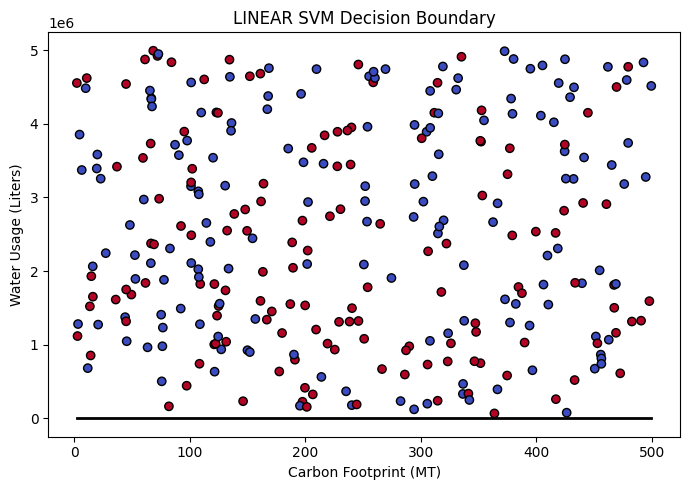

In [32]:
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import numpy as np

# Train LinearSVC on sampled data
X_vis = X_train_2D.sample(n=300, random_state=42)
y_vis = y_train_2D.loc[X_vis.index]

model = LinearSVC(C=1, max_iter=10000, random_state=42)
model.fit(X_vis, y_vis)

# Plot decision boundary manually (works because it's linear)
def plot_linear_svc_boundary(model, X, y, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=LabelEncoder().fit_transform(y), cmap=plt.cm.coolwarm, edgecolors='k')

    # Create decision boundary line
    coef = model.coef_[0]
    intercept = model.intercept_[0]
    x_vals = np.linspace(X.iloc[:, 0].min(), X.iloc[:, 0].max(), 100)
    y_vals = -(coef[0] * x_vals + intercept) / coef[1]

    plt.plot(x_vals, y_vals, color='black', linewidth=2)
    plt.xlabel("Carbon Footprint (MT)")
    plt.ylabel("Water Usage (Liters)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_linear_svc_boundary(model, X_vis, y_vis, "LINEAR SVM Decision Boundary")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


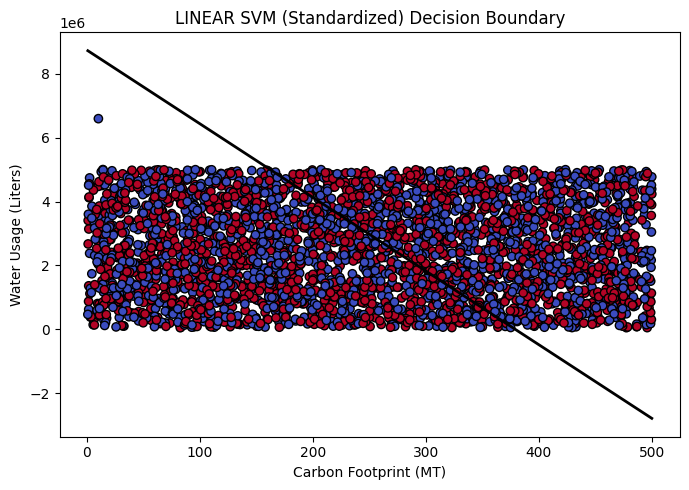

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
import numpy as np

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_2D)

# Train LinearSVC on scaled data
model_scaled = LinearSVC(C=1, max_iter=10000, random_state=42)
model_scaled.fit(X_scaled, y_train_2D)

# Plot decision boundary using original scale but transformed data
def plot_scaled_decision_boundary(model, X, y, scaler, title):
    X_scaled = scaler.transform(X)
    coef = model.coef_[0]
    intercept = model.intercept_[0]

    plt.figure(figsize=(7, 5))
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=LabelEncoder().fit_transform(y), cmap=plt.cm.coolwarm, edgecolors='k')

    # Generate decision line in original space
    x_vals = np.linspace(X.iloc[:, 0].min(), X.iloc[:, 0].max(), 100)
    x_scaled_vals = scaler.transform(np.column_stack((x_vals, np.full_like(x_vals, X.iloc[:, 1].mean()))))
    y_scaled_vals = -(coef[0] * x_scaled_vals[:, 0] + intercept) / coef[1]

    # Convert scaled y back to original scale
    y_unscaled = y_scaled_vals * scaler.scale_[1] + scaler.mean_[1]

    plt.plot(x_vals, y_unscaled, color='black', linewidth=2)
    plt.xlabel("Carbon Footprint (MT)")
    plt.ylabel("Water Usage (Liters)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_scaled_decision_boundary(model_scaled, X_train_2D, y_train_2D, scaler, "LINEAR SVM (Standardized) Decision Boundary")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


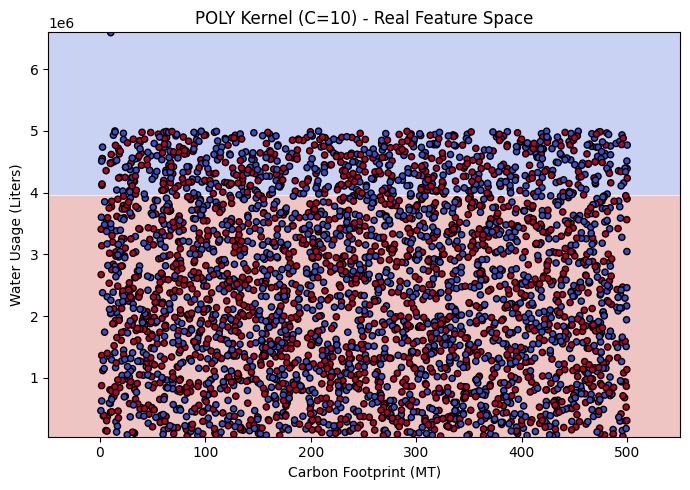

In [18]:
from sklearn.svm import SVC

# Train on full 2D training data
model_poly = SVC(kernel='poly', C=10, degree=3, gamma='scale', random_state=42)
model_poly.fit(X_train_2D, y_train_2D)

# Use the same meshgrid-based plotting function as before
plot_svm_decision_boundary(model_poly, X_train_2D, y_train_2D, "POLY Kernel (C=10) - Real Feature Space")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


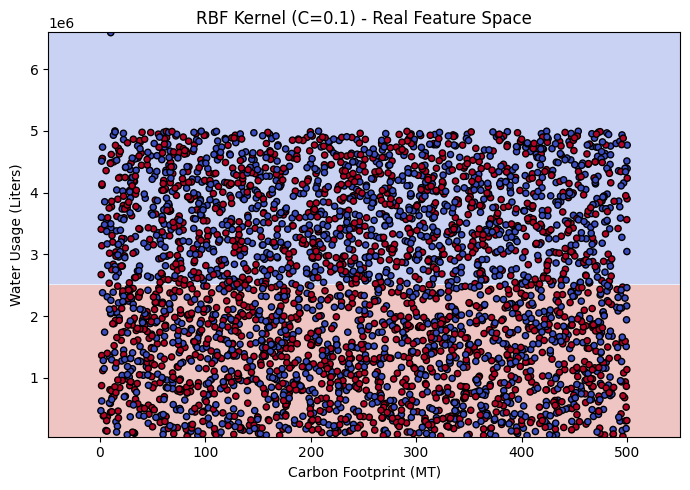

In [19]:
# Train on full 2D training data
model_rbf = SVC(kernel='rbf', C=0.1, gamma='scale', random_state=42)
model_rbf.fit(X_train_2D, y_train_2D)

# Use the same plotting function
plot_svm_decision_boundary(model_rbf, X_train_2D, y_train_2D, "RBF Kernel (C=0.1) - Real Feature Space")


🔷 LINEAR Kernel Confusion Matrices


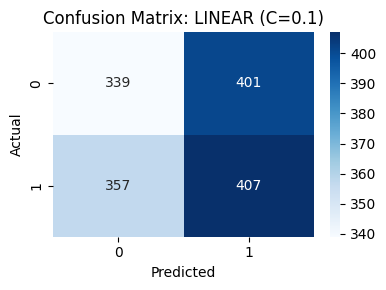

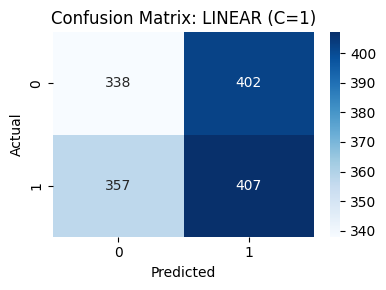

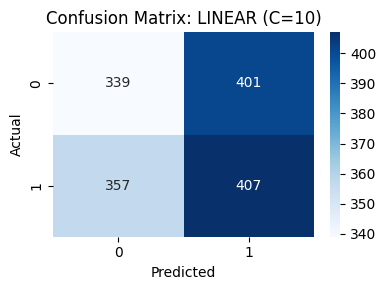

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Function to plot confusion matrix
def plot_conf_matrix(cm, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# --- Combine kernel results from previous cells ---
# Assuming kernel_results_linear, kernel_results_poly, and kernel_results_rbf
# are dictionaries from previous cells containing the results
kernel_results = {**kernel_results_linear, **kernel_results_poly, **kernel_results_rbf}

# --- Plot Linear Kernel Results ---
print("🔷 LINEAR Kernel Confusion Matrices")
for label, result in kernel_results.items():
    if "LINEAR" in label:
        plot_conf_matrix(result["conf_matrix"], f"Confusion Matrix: {label}")





🔶 POLY Kernel Confusion Matrices


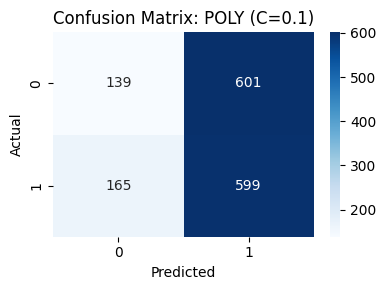

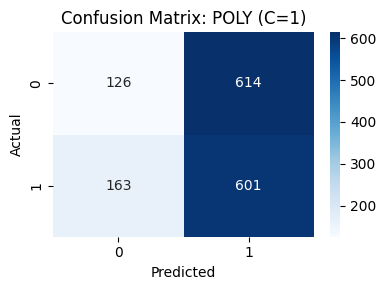

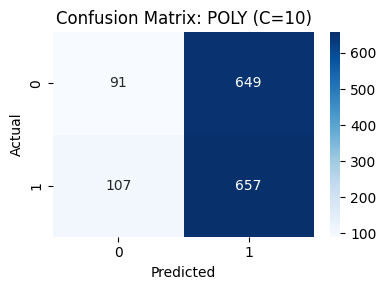

In [23]:
# --- Plot Polynomial Kernel Results ---
print("\n🔶 POLY Kernel Confusion Matrices")
for label, result in kernel_results.items():
    if "POLY" in label:
        plot_conf_matrix(result["conf_matrix"], f"Confusion Matrix: {label}")



🔸 RBF Kernel Confusion Matrices


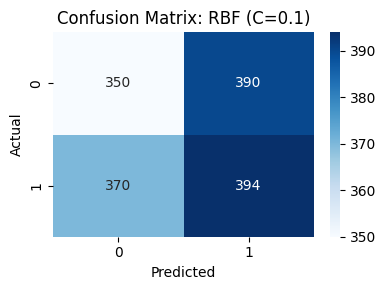

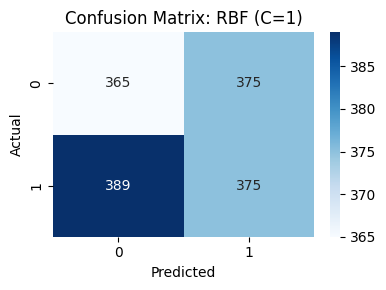

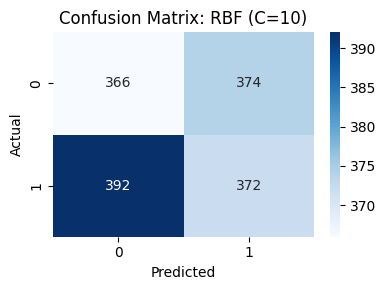

In [24]:
# --- Plot RBF Kernel Results ---
print("\n🔸 RBF Kernel Confusion Matrices")
for label, result in kernel_results.items():
    if "RBF" in label:
        plot_conf_matrix(result["conf_matrix"], f"Confusion Matrix: {label}")

In [27]:
kernel_results = {**kernel_results_linear, **kernel_results_poly, **kernel_results_rbf}

for label, result in kernel_results.items():
    print(f"\nAccuracy for {label}: {result['report']['accuracy']}")


Accuracy for LINEAR (C=0.1): 0.49601063829787234

Accuracy for LINEAR (C=1): 0.4953457446808511

Accuracy for LINEAR (C=10): 0.49601063829787234

Accuracy for POLY (C=0.1): 0.49069148936170215

Accuracy for POLY (C=1): 0.4833776595744681

Accuracy for POLY (C=10): 0.4973404255319149

Accuracy for RBF (C=0.1): 0.4946808510638298

Accuracy for RBF (C=1): 0.4920212765957447

Accuracy for RBF (C=10): 0.49069148936170215
